In [1]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import RegexpTokenizer
# Source - https://stackoverflow.com/a/79071153
# Posted by Carolina Goes, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-19, License - CC BY-SA 4.0

nltk.download('punkt_tab')
nltk.download('stopwords')

#from nltk.corpus import stopwords
#from nltk.tokenize import word_tokenize


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hsfac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hsfac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:


test_numbers = ["0", "69200", "2.1524", "200,000", "1357.15"]
test_dates = ["Jan. 18, 2018", "January 24, 2018", "Feb. 23", "April 2017", "JAN 31.2018", "13th OCTOBER 2017",
              "JAN 31.2018", "APRIL 21/2017", "January 15", "18, 2018", "Jan.12, 2018", "September of 2017",
              "2018 March", "July 5, 2016"]
test_emails = ["tammyjcoffman@gmail.com", "info@treadwells-london.com", "rscdesigns@tampabay.rr.com"]
test_urls = ["Shutterstock.com", 
             "http://www.wptv.com/", 
             "https://vimeo.com/ondemand/Awakeningof12strands", 
             "https://worldgovernmentsummit.org/api/publications/document?id=23747dc4-e97c-6578-b2f8-ff0000a7ddb6",
             "https://www.youtube.com/watch?v=dQw4w9WgXcQ",
             ]


pattern_newlines = re.compile(r"\n")
pattern_tabs = re.compile(r"\t")
pattern_multiplewhitespace = re.compile(r"\s{2,}")

pattern_number = re.compile(r"\d[\d,\.]*")

months = "January|February|March|April|May|June|July|August|September|October|November|December|Jan|Feb|Mar|Apr|Jun|Aug|Sep|Oct|Nov|Dec"
pattern_date = re.compile(rf"(({months})\.? ?\d{{1,2}}([,\.]?[ /]?\d{{4}}\.?)?)|"
                          rf"(({months}) \d{{4}}\.?)|"
                          r"(\d{1,4}-\d{1,2}-\d{1,4})|"
                          rf"(\d{{1,2}}(\.|st|nd|th)? ({months}) (\d{{4}})?)|"
                          r"(\d{1,2}, \d{1,4})|"
                          rf"(({months}) of \d{{4}})|"
                          rf"(\d{{4}} ({months}))",
                          flags=re.IGNORECASE)

pattern_email = re.compile(r"\w+@([\w-]+\.)+\w+")
pattern_url = re.compile(r"(\w+://)?\w+\.\w+(.\w+)?[/\w?=-]*")

def clean_data(text):
    try:
        import re
        pattern_newlines = re.compile(r"\n")
        pattern_tabs = re.compile(r"\t")
        pattern_multiplewhitespace = re.compile(r"\s{2,}")

        pattern_number = re.compile(r"\d[\d,\.]*")

        months = "January|February|March|April|May|June|July|August|September|October|November|December|Jan|Feb|Mar|Apr|Jun|Aug|Sep|Oct|Nov|Dec"
        pattern_date = re.compile(rf"(({months})\.? ?\d{{1,2}}([,\.]?[ /]?\d{{4}}\.?)?)|"
                                rf"(({months}) \d{{4}}\.?)|"
                                r"(\d{1,4}-\d{1,2}-\d{1,4})|"
                                rf"(\d{{1,2}}(\.|st|nd|th)? ({months}) (\d{{4}})?)|"
                                r"(\d{1,2}, \d{1,4})|"
                                rf"(({months}) of \d{{4}})|"
                                rf"(\d{{4}} ({months}))",
                                flags=re.IGNORECASE)

        pattern_ = re.compile(r"\w+@([\w-]+\.)+\w+")
        pattern_url = re.compile(r"(\w+://)?\w+\.\w+(.\w+)?[/\w?=-]*")
        text = pattern_multiplewhitespace.sub(" ", text)
        text = pattern_newlines.sub("", text)
        text = pattern_tabs.sub("", text)
        text = text.lower()
        text = pattern_url.sub("<URL>", text)
        text = pattern_email.sub("<EMAIL>", text)
        text = pattern_date.sub("<DATE>", text)
        text = pattern_number.sub("<NUM>", text)
    except:
        print(text)
        return text
    return text


tests = [(pattern_number, test_numbers),
         (pattern_date, test_dates), 
         (pattern_email, test_emails), 
         (pattern_url, test_urls)]

for pattern, test_cases in tests:
    for test_case in test_cases:
        result = pattern.fullmatch(test_case)
        if result is None:
            raise re.PatternError(f"Regular expression {pattern.pattern} did not match {test_case}.")
        else:
            print(repr(result.string))

'0'
'69200'
'2.1524'
'200,000'
'1357.15'
'Jan. 18, 2018'
'January 24, 2018'
'Feb. 23'
'April 2017'
'JAN 31.2018'
'13th OCTOBER 2017'
'JAN 31.2018'
'APRIL 21/2017'
'January 15'
'18, 2018'
'Jan.12, 2018'
'September of 2017'
'2018 March'
'July 5, 2016'
'tammyjcoffman@gmail.com'
'info@treadwells-london.com'
'rscdesigns@tampabay.rr.com'
'Shutterstock.com'
'http://www.wptv.com/'
'https://vimeo.com/ondemand/Awakeningof12strands'
'https://worldgovernmentsummit.org/api/publications/document?id=23747dc4-e97c-6578-b2f8-ff0000a7ddb6'
'https://www.youtube.com/watch?v=dQw4w9WgXcQ'


In [3]:
data=pd.read_csv("news_sample.csv")
print(data.iloc(0))

nltk how a vocabluty for stop words, which we chose to use since it might be as good as any of the differnt. And it has a SnowballStemmer which is a good stemmer, since it will stem words.

In [4]:
def stop_word_remove(sentence):
    
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem.snowball import SnowballStemmer
    try:
        tokens=nltk.word_tokenize(sentence)
        #print(len(set(tokens)))
        stop_words=set(stopwords.words('english'))
        
        filtered_words =[word for word in tokens if word not in stop_words]
        #print(len(set(filtered_words)))
    except:
        return sentence
    return filtered_words
    


In [5]:
def stemming_words(sentence):
    #print(sentence)
    try:
        from nltk.stem.snowball import SnowballStemmer
        #print(len(set(sentence)))
        stemmer = SnowballStemmer("english")
        without_stem=[(stemmer.stem(word)) for word in sentence]
        #print(len(set(without_stem)))
    except:
        return"null"
    return " ".join(without_stem)

In [6]:
t=stop_word_remove("dear readers, we are excited to announce that the voice of russia has changed its name and moved over to a new website. we are now known as sputnik news agency and radio. you can find all the latest stories and updates here: <URL>")
print(stemming_words(t))#))
#print(stemming_words(
    #
    # stop_word_remove("dear readers, we are excited to announce that the voice of russia has changed its name and moved over to a new website. we are now known as sputnik news agency and radio. you can find all the latest stories and updates here: <URL>")))

dear reader , excit announc voic russia chang name move new websit . known sputnik news agenc radio . find latest stori updat : < url >


In [7]:
def stem_stop_words(sentence):
    return(stemming_words(stop_word_remove(sentence)))

In [8]:
def full_clean(sentence):
    return stem_stop_words(clean_data(sentence))

In [9]:
for element in data["content"]:
    stem_stop_words(clean_data(element))


In [10]:
def size_of_vocab(text,string=False):
    if string:
        return len((set(text.split(" "))))
    else:
        return len(set(text))

In [11]:
#data2=pd.read_csv("995,000_rows_stemming_words.csv",dtype = str)
import time
from parallel_pandas import ParallelPandas
import swifter
import multiprocessing
#print(data2.shape)
#pd.read_csv("995,000_rows_stemming_words.csv",dtype = str,skiprows=10^6)
#for chunk in pd.read_csv("995,000_rows_stemming_words.csv",dtype = str,chunksize=10000):
   # print(chunk.shape)
#data2=pd.read_csv("995,000_rows_stop_word_remove.csv",nrows=10)

#data2=pd.read_csv("995,000_rows_stemming_words.csv",dtype = str,skiprows=10,nrows=10)
#t=data2["content"][0].split(',')
#t=data2[data2.columns].tolist()

#print(list(t))
#print(stemming_words(list(t)))
#print(data2)


In [12]:
ParallelPandas.initialize(n_cpu=16, split_factor=16, disable_pr_bar=False)

In [13]:
ParallelPandas.initialize(n_cpu=16, split_factor=16, disable_pr_bar=False)

tid1=time.time()
def t(x):
    return t
#data2["content"]=data2["content"].p_apply(clean_data)


#data2.to_csv("995,000_rows_clean_data.csv", index=False)
#print(len(set((data2["content"].str.cat()).split(" "))))

#print(len((set(nltk.word_tokenize(data2["content"].str.cat())))))
count=0
#for element in pd.read_csv("995,000_rows_clean_data.csv",dtype = str,chunksize=500000):
"""
for element in pd.read_csv("995,000_rows_clean_data.csv",dtype = str,chunksize=100000):
    if count==0:
        element["content"]=element["content"].p_apply(stop_word_remove)
        element["content"]=element["content"].p_apply(stemming_words)
        element.to_csv("995,000_rows_stemming_words.csv", index=False)
        print("hej")
        count+=1
    else:
        element["content"]=element["content"].p_apply(stop_word_remove)
        element["content"]=element["content"].p_apply(stemming_words)
        element.to_csv("995,000_rows_stemming_words.csv",mode='a', header=False,index=False)
"""

#data2["content"]=data2["content"].p_apply(stop_word_remove)
#print(len(set(data2["content"].sum())))
#data2.to_csv("995,000_rows_stop_word_remove.csv", index=False)

   
   

#print(len(set(data2["content"].sum())))
#(lambda x:full_clean(x))

print(time.time()-tid1)

0.0


In [14]:
#result=data2.p_describe()

We loaded the data in using pandas, and then we could use each of them as a value and of text. The reason we do this is because it's easy to load in data from csv file using pandas. One more thing is that we saved the values after working with each colum as either a string or a list of string. The reason behind this was that a reguler exprison uses an entire string while snowball and nltk both uses list of strings that are the tokenises versions of the enitre string.

The problem with working with was it that there most likely was null values, since some of them got reqrested as float and not string, so that was an issue, and another issue was the fact that the data set was so long that it took a long time, and it hadd issues loadning. And steming the words made the data file some how really large. The tokennsier also marked \<\Url> as 3 differnt words. We tried loading list into csv file using pandas, but it took it as strings and therefore in the final fille we are using string as the end result.

In [15]:
def find_url(sentence):
    try:
        return sentence.count("< url >")
    except:
        return 0

In [16]:
def find_dates(text):
    try:

        return text.count("< date >")
    except:
        return 0
def find_numb(text):
    try:

        return text.count("< num >")
    except:
        return 0
def find_mail(text):
    try:

        return text.count("< email >")
    except:
        return 0


In [17]:
#data2=pd.read_csv("995,000_rows_stemming_words.csv",dtype = str,nrows=10)
data3= pd.read_csv("995,000_rows_stemming_words.csv",dtype = str)
data3["date"]=data3["content"].p_apply(find_dates)
data3["email"]=data3["content"].p_apply(find_mail)
data3["url"]=data3["content"].p_apply(find_url)
data3["num"]=data3["content"].p_apply(find_numb)
    #element.to_csv("995,000_rows_stemming_words.csv", index=False)
      

FIND_DATES DONE:   0%|          | 0/995000 [00:00<?, ?it/s]

FIND_MAIL DONE:   0%|          | 0/995000 [00:00<?, ?it/s]

FIND_URL DONE:   0%|          | 0/995000 [00:00<?, ?it/s]

FIND_NUMB DONE:   0%|          | 0/995000 [00:00<?, ?it/s]

In [18]:
print(data3["date"].sum())
print(data3["email"].sum())
print(data3["url"].sum())
print(data3["num"].sum())

933792
1
1990668
7628682


In [19]:
from collections import Counter

In [20]:
samlede_string=data3["content"].str.split(" ").explode()#.value_count()

In [21]:
count_value=samlede_string.value_counts()

In [ ]:
import matplotlib.pyplot as plt

<Axes: xlabel='content'>

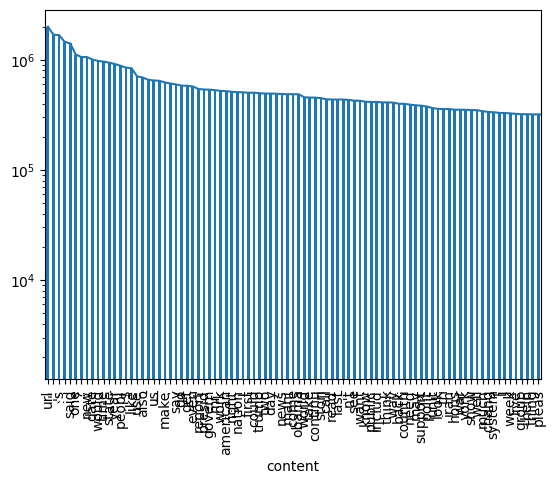

In [43]:
#count_value[11:100].plot(kind='bar',logy=True)
count_value[11:10000].plot(logy=True)
count_value[11:100].plot(kind='bar',logy=True)

In [ ]:
data_sum=data3["counters"].sum()

Different

In [39]:
dat3 = data3.sample(frac=1).reset_index(drop=True)
trainset=data3.iloc[:int(len(data3)*0.80)]
validation=data3.iloc[int(len(data3)*0.80):int(len(data3)*0.90)]
test=data3.iloc[int(len(data3)*0.90):]

trainset.to_csv("995,000_trainset_80.csv", index=False)
validation.to_csv("995,000_vail_10_set.csv", index=False)
test.to_csv("995,000_test_10_set.csv", index=False)

